<a href="https://colab.research.google.com/github/Renju-rl/Git-hub-DSA/blob/main/intermediate_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TRAIN File

In [232]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier #KNN
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score
from sklearn.naive_bayes import GaussianNB #NB
from sklearn.tree import DecisionTreeClassifier #DT
from sklearn.svm import SVC #SVM
from sklearn.model_selection import GridSearchCV


In [233]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [234]:
fp = '/content/drive/MyDrive/DSA/Data/train_LZdllcl.csv'
t_f = pd.read_csv(fp)
t_f.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [235]:
t_f.shape

(54808, 14)

In [236]:
t_f.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met >80%', 'awards_won?',
       'avg_training_score', 'is_promoted'],
      dtype='object')

In [237]:
t_f.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.351974,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.477590,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,1.000000,99.000000,1.000000


In [238]:
t_f.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


In [239]:
t_f.dtypes

,0
employee_id,int64
department,object
region,object
education,object
gender,object
recruitment_channel,object
no_of_trainings,int64
age,int64
previous_year_rating,float64
length_of_service,int64


In [240]:
t_f.isna().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


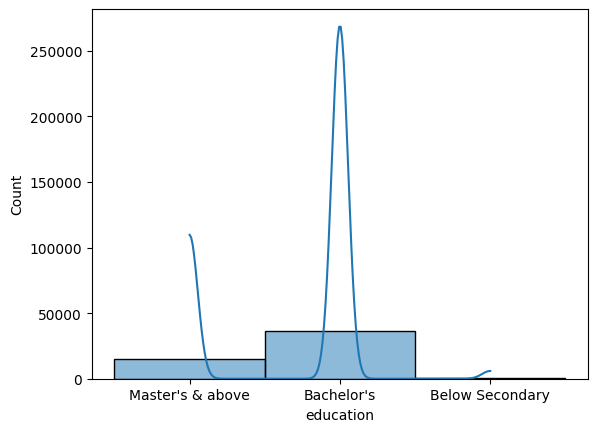

In [241]:
sns.histplot(t_f['education'], kde=True)
plt.show()


In [242]:
t_f['education']=t_f['education'].fillna(t_f['education'].mode()[0])
t_f['previous_year_rating'] = t_f['previous_year_rating'].fillna(t_f['previous_year_rating'].mean())#here mean use because it is bellcurve data not skewed data
t_f.isna().sum()

,0
employee_id,0
department,0
region,0
education,0
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,0
length_of_service,0


In [243]:
t_f.duplicated().sum()

np.int64(0)

In [244]:
t_f.nunique()

,0
employee_id,54808
department,9
region,34
education,3
gender,2
recruitment_channel,3
no_of_trainings,10
age,41
previous_year_rating,6
length_of_service,35


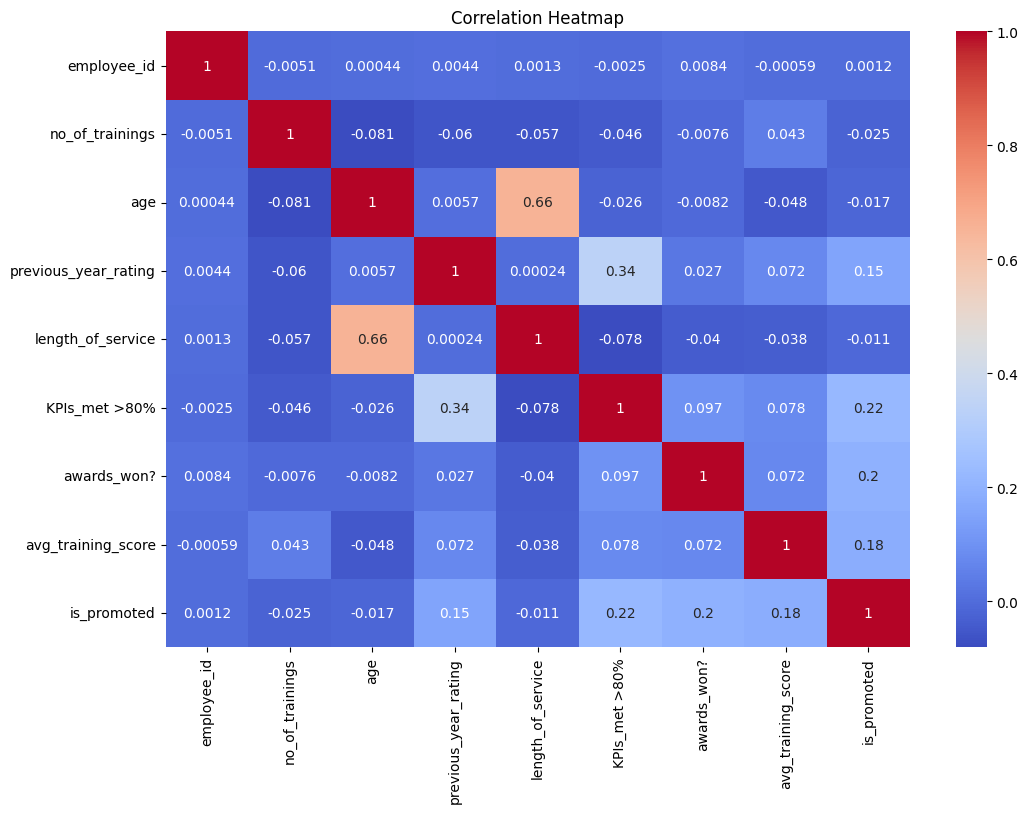

In [245]:
corr = corr = t_f.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [246]:
num_cols = t_f.select_dtypes(include='number').columns
print(num_cols)

Index(['employee_id', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met >80%', 'awards_won?',
       'avg_training_score', 'is_promoted'],
      dtype='object')


In [247]:
for cols in num_cols:
  q1  = t_f[cols].quantile(0.25)
  q3  = t_f[cols].quantile(0.75)
  iqr = q3 - q1

  lower = q1 - 1.5*iqr
  upper = q3 + 1.5*iqr

  outliers = t_f[(t_f[cols] < lower) | (t_f[cols] > upper)]
  print(f"{cols} - Outliers count: {outliers.shape[0]}")


employee_id - Outliers count: 0
no_of_trainings - Outliers count: 10430
age - Outliers count: 1435
previous_year_rating - Outliers count: 6223
length_of_service - Outliers count: 3489
KPIs_met >80% - Outliers count: 0
awards_won? - Outliers count: 1270
avg_training_score - Outliers count: 0
is_promoted - Outliers count: 4668


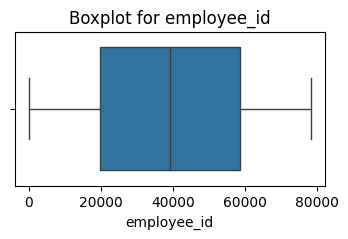

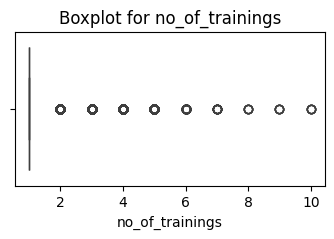

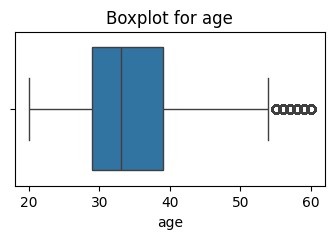

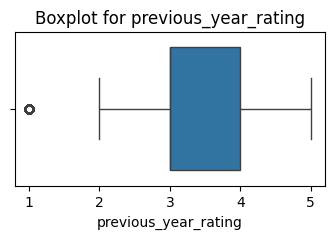

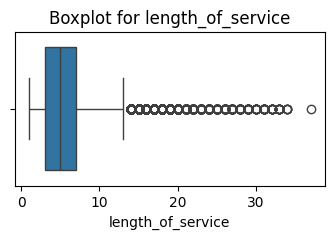

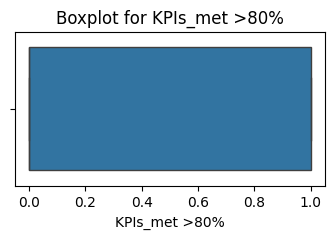

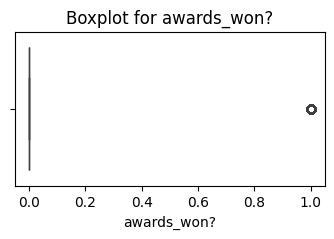

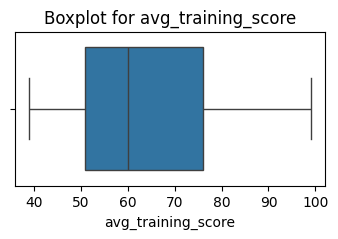

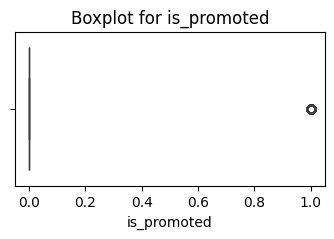

In [248]:
for cols in num_cols:
    plt.figure(figsize=(4, 2))
    sns.boxplot(x=t_f[cols])
    plt.title(f"Boxplot for {cols}")
    plt.show()

In [249]:
#frequency Encoding
region_freq_map = t_f['region'].value_counts(normalize=True).to_dict()
t_f['region'] = t_f['region'].map(region_freq_map)

In [250]:
t_f['region'].value_counts()

,count
region,
0.225204,12343
0.117282,6428
0.088363,4843
0.051233,2808
0.048314,2648
0.041235,2260
0.035305,1935
0.031072,1703
0.030269,1659


In [251]:
#Label Encoding
label_cols = ['department', 'education', 'gender', 'recruitment_channel']

le = LabelEncoder()
for col in label_cols:
    t_f[col] = le.fit_transform(t_f[col])
display(t_f.head())

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,7,0.088363,2,0,2,1,35,5.0,8,1,0,49,0
1,65141,4,0.117282,0,1,0,1,30,5.0,4,0,0,60,0
2,7513,7,0.015947,0,1,2,1,34,3.0,7,0,0,50,0
3,2542,7,0.021438,0,1,0,2,39,1.0,10,0,0,50,0
4,48945,8,0.041235,0,1,0,1,45,3.0,2,0,0,73,0


In [252]:
t_f.shape

(54808, 14)

In [253]:
#Scaling and spliting

X = t_f.drop(['is_promoted','employee_id'], axis=1)
y = t_f['is_promoted']

#Train_test_split
X_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(x_test)

##Modeling through classification
here we use classification because the targert column is not continuous numeric value

In [254]:
#1, Linear Regression
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

LogisticRegression()

In [255]:
y_pred = lr.predict(x_test_scaled)

In [256]:
print(f'accuracy_score= {accuracy_score(y_test,y_pred)}')
print(f'precision= {precision_score(y_test,y_pred)}')
print(f'f1= {f1_score(y_test,y_pred)}')
print(f'recall= {recall_score(y_test,y_pred)}')
print(f'conf_matrix= {confusion_matrix(y_test,y_pred)}')
print(f'classification_report= {classification_report(y_test,y_pred)}')

accuracy_score= 0.9164386060937785
precision= 0.6296296296296297
f1= 0.12927756653992395
recall= 0.07203389830508475
conf_matrix= [[9978   40]
 [ 876   68]]
classification_report=               precision    recall  f1-score   support

           0       0.92      1.00      0.96     10018
           1       0.63      0.07      0.13       944

    accuracy                           0.92     10962
   macro avg       0.77      0.53      0.54     10962
weighted avg       0.89      0.92      0.88     10962



In [257]:
#2,KNN
#Euclidian

#we need to figure out the optimum value for k.
#to do that, we will check which value of k is giving highest accuracy.

accuracy_list = []
neighbors_range = np.arange(1,30)

for k in neighbors_range:
  classifier = KNeighborsClassifier(n_neighbors=k , metric='minkowski',p=2)  # initialising classifier for iteration using Euclidian p=2
  #Training the ML model
  classifier.fit(X_train_scaled, y_train)
  y_pred_eu=classifier.predict(x_test_scaled)  #predict using trained ML model
  acc = accuracy_score(y_test,y_pred_eu)  # evaluate the ML model
  accuracy_list.append(acc) #appending acc list with accuracy achieved for each value of k

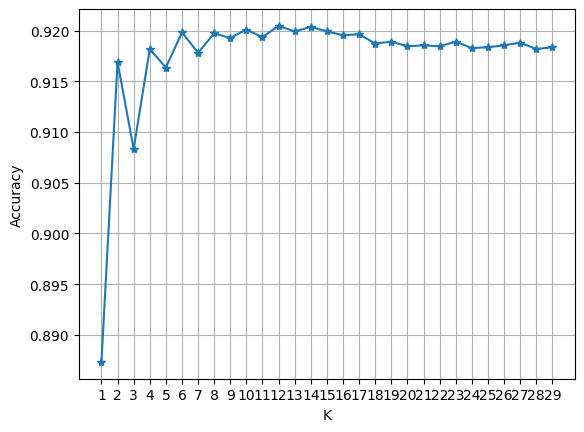

In [258]:
plt.plot(neighbors_range, accuracy_list,'*-')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.xticks(neighbors_range)
plt.grid()

In [259]:
#taking k as 6
classifier_knn = KNeighborsClassifier(n_neighbors=6, metric='euclidean')
classifier_knn.fit(X_train_scaled,y_train)
y_pred_knn_eu = classifier_knn.predict(x_test_scaled)
acc_knn=accuracy_score(y_test,y_pred_knn_eu)
prec_knn=precision_score(y_test,y_pred_knn_eu)
rec_knn=recall_score(y_test,y_pred_knn_eu)
f1_knn=f1_score(y_test,y_pred_knn_eu)

print('Accuracy:',acc_knn)
print('Precision:',prec_knn)
print('Recall:',rec_knn)
print('F1 Score:',f1_knn)
confusion_matrix(y_test,y_pred_knn_eu)

Accuracy: 0.9198139025725233
Precision: 0.6923076923076923
Recall: 0.1239406779661017
F1 Score: 0.21024258760107817


array([[9966,   52],
       [ 827,  117]])

In [260]:
#Manhattan

accuracy_list1 = []
neighbors_range1 = np.arange(1,30)

for k in neighbors_range:
  classifier1 = KNeighborsClassifier(n_neighbors=k , metric='minkowski',p=1)  # initialising classifier for iteration using manhattan p=1
  #Training the ML model
  classifier1.fit(X_train_scaled, y_train)
  y_pred_mn=classifier1.predict(x_test_scaled)
  acc1 = accuracy_score(y_test,y_pred_mn)
  accuracy_list1.append(acc1)

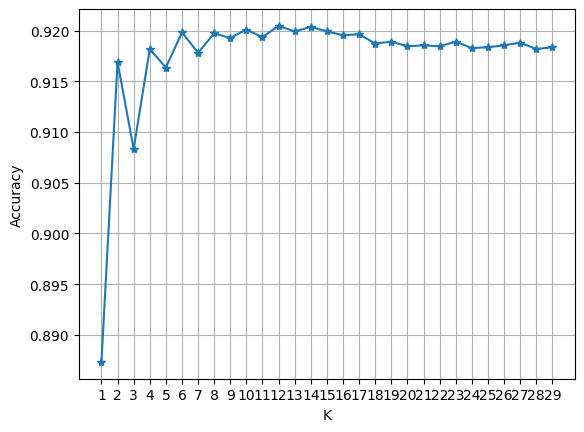

In [261]:
plt.plot(neighbors_range, accuracy_list,'*-')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.xticks(neighbors_range)
plt.grid()

In [262]:
classifier1_knn = KNeighborsClassifier(n_neighbors=6, metric='manhattan') #using K=6
classifier1_knn.fit(X_train_scaled,y_train)
y_pred_knn_mn = classifier1_knn.predict(x_test_scaled)
acc_knn1=accuracy_score(y_test,y_pred_knn_mn)
prec_knn1=precision_score(y_test,y_pred_knn_mn)
rec_knn1=recall_score(y_test,y_pred_knn_mn)
f1_knn1=f1_score(y_test,y_pred_knn_mn)

print('Accuracy:',acc_knn1)
print('Precision:',prec_knn1)
print('Recall:',rec_knn1)
print('F1 Score:',f1_knn1)
confusion_matrix(y_test,y_pred_knn_mn)

Accuracy: 0.919722678343368
Precision: 0.7253521126760564
Recall: 0.10911016949152542
F1 Score: 0.18968692449355432


array([[9979,   39],
       [ 841,  103]])

In [263]:
#3, Nave Bayes

#initializing the model
nb=GaussianNB()
#training the model
nb.fit(X_train_scaled,y_train)
#predict using trained ML model
y_pred_nb=nb.predict(x_test_scaled)
#evaluate the model
acc_nb=accuracy_score(y_test,y_pred_nb)
prec_nb=precision_score(y_test,y_pred_nb)
rec_nb=recall_score(y_test,y_pred_nb)
f1_nb=f1_score(y_test,y_pred_nb)


print('Accuracy:',acc_nb)
print('Precision:',prec_nb)
print('Recall:',rec_nb)
print('F1 Score:',f1_nb)
confusion_matrix(y_test,y_pred_nb)

Accuracy: 0.911421273490239
Precision: 0.4482758620689655
Recall: 0.1239406779661017
F1 Score: 0.1941908713692946


array([[9874,  144],
       [ 827,  117]])

In [264]:
#4,desicion tree

#initializing the model
dt=DecisionTreeClassifier()
#training the model
dt.fit(X_train_scaled,y_train)
#predict using trained ML model
y_pred_dt=dt.predict(x_test_scaled)
#evaluate the model
acc_dt=accuracy_score(y_test,y_pred_dt)
prec_dt= precision_score(y_test,y_pred_dt)
rec_dt=recall_score(y_test,y_pred_dt)
f1_dt=f1_score(y_test,y_pred_dt)

print('Accuracy:',acc_dt)
print('Precision:',prec_dt)
print('Recall:',rec_dt)
print('F1 Score:',f1_dt)
confusion_matrix(y_test,y_pred_dt)

Accuracy: 0.8983762087210363
Precision: 0.415506958250497
Recall: 0.4427966101694915
F1 Score: 0.4287179487179487


array([[9430,  588],
       [ 526,  418]])

In [265]:
#5,SVM

svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=55)  ##initializing the model
svm_clf.fit(X_train_scaled, y_train)   ##training the model
y_pred_sv = svm_clf.predict(x_test_scaled)  ##training the model
#evaluating the model
acc_sv=accuracy_score(y_test,y_pred_sv)
prec_sv= precision_score(y_test,y_pred_sv)
rec_sv=recall_score(y_test,y_pred_sv)
f1_sv=f1_score(y_test,y_pred_sv)


print('Accuracy:',acc_sv)
print('Precision:',prec_sv)
print('Recall:',rec_sv)
print('F1 Score:',f1_sv)
confusion_matrix(y_test,y_pred_sv)

Accuracy: 0.9188104360518153
Precision: 0.8214285714285714
Recall: 0.07309322033898305
F1 Score: 0.13424124513618677


array([[10003,    15],
       [  875,    69]])

##Tuning using grid search cv

In [266]:

param_grid_knn = {
    'n_neighbors': list(range(1, 31)),
    'metric': ['euclidean', 'manhattan']
}

print(param_grid_knn)

{'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30], 'metric': ['euclidean', 'manhattan']}


In [267]:
knn = KNeighborsClassifier()
grid_search_knn = GridSearchCV(estimator=knn, param_grid=param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)

print("GridSearchCV for KNN initialized.")

GridSearchCV for KNN initialized.


In [268]:
grid_search_knn.fit(X_train, y_train)

print("GridSearchCV fitting complete.")

GridSearchCV fitting complete.


In [269]:
print("Best parameters for KNN:", grid_search_knn.best_params_)
print("Best score for KNN:", grid_search_knn.best_score_)

Best parameters for KNN: {'metric': 'euclidean', 'n_neighbors': 9}
Best score for KNN: 0.9297541393420614


In [270]:
best_knn = grid_search_knn.best_estimator_
y_pred_best_knn = best_knn.predict(x_test_scaled)

print("KNN (Fine-Tuned) Performance on Test Set:")
print(f'Accuracy: {accuracy_score(y_test, y_pred_best_knn)}')
print(f'Precision: {precision_score(y_test, y_pred_best_knn)}')
print(f'Recall: {recall_score(y_test, y_pred_best_knn)}')
print(f'F1 Score: {f1_score(y_test, y_pred_best_knn)}')
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_best_knn))

KNN (Fine-Tuned) Performance on Test Set:
Accuracy: 0.9138843276774311
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
Confusion Matrix:
 [[10018     0]
 [  944     0]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#Testing Data

In [271]:
fp_t = '/content/drive/MyDrive/DSA/Data/test_2umaH9m.csv'
te_f = pd.read_csv(fp_t)
te_f.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61


In [272]:
te_f.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23490 entries, 0 to 23489
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           23490 non-null  int64  
 1   department            23490 non-null  object 
 2   region                23490 non-null  object 
 3   education             22456 non-null  object 
 4   gender                23490 non-null  object 
 5   recruitment_channel   23490 non-null  object 
 6   no_of_trainings       23490 non-null  int64  
 7   age                   23490 non-null  int64  
 8   previous_year_rating  21678 non-null  float64
 9   length_of_service     23490 non-null  int64  
 10  KPIs_met >80%         23490 non-null  int64  
 11  awards_won?           23490 non-null  int64  
 12  avg_training_score    23490 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 2.3+ MB


In [273]:
te_f.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
count,23490.000000,23490.000000,23490.000000,21678.000000,23490.000000,23490.000000,23490.000000,23490.000000
mean,39041.399149,1.254236,34.782929,3.339146,5.810387,0.358834,0.022776,63.263133
std,22640.809201,0.600910,7.679492,1.263294,4.207917,0.479668,0.149191,13.411750
min,3.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000
25%,19370.250000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000
50%,38963.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000
75%,58690.000000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000
max,78295.000000,9.000000,60.000000,5.000000,34.000000,1.000000,1.000000,99.000000


In [274]:
te_f.dtypes

,0
employee_id,int64
department,object
region,object
education,object
gender,object
recruitment_channel,object
no_of_trainings,int64
age,int64
previous_year_rating,float64
length_of_service,int64


In [275]:
te_f.isna().sum()

,0
employee_id,0
department,0
region,0
education,1034
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,1812
length_of_service,0


In [276]:
te_f['education']=te_f['education'].fillna(te_f['education'].mode()[0])
te_f['previous_year_rating']=te_f['previous_year_rating'].fillna(te_f['previous_year_rating'].mean())
te_f.isna().sum()

,0
employee_id,0
department,0
region,0
education,0
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,0
length_of_service,0


##Encoding

In [277]:
#frequency encoding
region_freq_map = te_f['region'].value_counts(normalize=True).to_dict()
te_f['region'] = te_f['region'].map(region_freq_map)

In [278]:
#Label Encoding
for col in label_cols:
    te_f[col] = le.fit_transform(te_f[col])

#Scaling

In [299]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(x_test)   # for evaluation
te_f_scaled    = scaler.transform(te_f)     # for submission

best_knn.fit(X_train_scaled, y_train)


KNeighborsClassifier(metric='euclidean', n_neighbors=9)

In [300]:
y_pred_te_f = best_knn.predict(te_f_scaled)


#Create submission file

In [304]:
sample_sub = pd.read_csv('/content/drive/MyDrive/DSA/Data/sample_submission_M0L0uXE.csv')
sample_sub['is_promoted'] = y_pred_te_f

In [305]:
sample_sub.to_csv('new_submission.csv', index=False)


In [306]:
from google.colab import files
files.download('new_submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>